# QENS Benzene Analysis


In [1]:
import os
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, nnls, minimize
from scipy.signal import fftconvolve

warnings.filterwarnings('ignore')


In [2]:
# nxspe files should sit next to this notebook

data_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(data_dir, 'results')
os.makedirs(save_dir, exist_ok=True)



working with .nxspe binary file format with specific structure  

define byte offsets for different data sections in the file  

set constants for detector count (249), energy bins (320), and byte offsets for energy edges, data, and errors  

proper file parsing parameters for reading binary data


In [3]:
n_det  = 249       # detector groups
n_bin  = 320       # energy bins per detector
off_e   = 0x30c0   # byte offset: energy edges
off_d   = 0x41b8   # byte offset: S(Q,w) data
off_err = 0x9fbb8  # byte offset: errors


## define detector angles

detectors arranged at specific angles covering 3.5-140 degrees 

create array of detector angles for Q-value calculations  

used linspace to generate 249 detector angles evenly spaced across the range  

complete angular coverage for momentum transfer calculations


In [4]:
# angles run 3.5 -> 140 degrees across 249 groups
two_theta = np.linspace(3.5, 140.0, n_det)


## physical constants
QENS analysis requires physical constants for energy and momentum calculations  

 set neutron mass, reduced Planck constant, energy conversion factors, and hbar_mevps in meV·ps units  



In [5]:
mn       = 1.6749e-27   # neutron mass, kg
hbar     = 1.0546e-34   # J.s
mev_j    = 1.6022e-22   # 1 meV in joules
hbar_mevps = 0.6582     # hbar in meV.ps — used throughout the model equations

print('setup done, saving to:', save_dir)


setup done, saving to: /Users/shubhamshinde/Desktop/QENS Analysis/results


read NXSSPE File Function

need to parse binary .nxspe files containing QENS data  

create function to extract data, metadata, and calculate Q-values  

implemented binary file reading, energy axis creation, data reshaping, quality filtering, and Q-value calculation  

In [6]:
def read_nxspe(path):
    """
    Read a Pelican .nxspe file. Returns a plain dict with numpy arrays.
    """
    name  = os.path.basename(path)
    parts = name.replace('.nxspe', '').split('_')
    temp  = int(parts[1])
    ei    = int(parts[2]) / 100.0   # '360' -> 3.60 meV
    kind  = parts[3]                # 'inc' or 'coh'

    with open(path, 'rb') as f:
        raw = f.read()


    edges = np.frombuffer(raw[off_e : off_e + (n_bin+1)*8], dtype='<f8')
    e_raw = 0.5 * (edges[:-1] + edges[1:])


    n    = n_det * n_bin
    data = np.frombuffer(raw[off_d   : off_d   + n*8], dtype='<f8').reshape(n_det, n_bin).copy()
    errs = np.frombuffer(raw[off_err : off_err + n*8], dtype='<f8').reshape(n_det, n_bin).copy()


    good = np.array([np.sum(np.isfinite(data[i]) & (data[i] > 0)) > n_bin // 2
        for i in range(n_det)])

    ki = np.sqrt(2 * mn * ei * mev_j) / hbar * 1e-10   # Angstrom^-1
    q  = 2 * ki * np.sin(np.radians(two_theta / 2))
    return dict(name=name, temp=temp, ei=ei, kind=kind,
                e_raw=e_raw, data=data, errs=errs,
                good=np.where(good)[0], q=q)


## fit elastic peak function

need to determine energy offset and resolution from elastic peak  

fit Gaussian to elastic peak for energy calibration  

averaged low-Q detectors, fitted Gaussian with bounds, calculated energy offset e0 and width  

energy axis calibration and resolution parameters for all datasets


In [7]:
def fit_elastic_peak(d):
    """
    Fit a Gaussian to the elastic peak (averaged over lowest-Q detectors)
    to measure the energy offset e0.

    Width from INC peaks is NOT the instrument resolution — INC peaks are
    broadened by QENS. That gets fixed from the COH file in the next cell.
    """
    good  = d['good']
    n_low = max(3, len(good) // 7)
    e     = d['e_raw']


    avg = np.nanmean([d['data'][i] for i in good[:n_low]], axis=0)
    avg = np.where(np.isfinite(avg), avg, 0)

    def gauss(x, a, mu, sig, bg):
        return a * np.exp(-0.5 * ((x - mu) / sig)**2) + bg

    pk = np.argmax(avg)
    try:
        popt, _ = curve_fit(gauss, e, avg,
                            p0=[avg[pk], e[pk], 0.05, avg.min()],
                            bounds=([-np.inf, e[0], 1e-4, -np.inf],
                                    [ np.inf, e[-1], 2.0,  np.inf]),
                            maxfev=8000)
        e0, sig_raw = popt[1], abs(popt[2])
    except:
        e0, sig_raw = e[pk], 0.043   # fallback if fit diverges

    d['e0']      = e0
    d['sig_raw'] = sig_raw
    d['e']       = e - e0   # corrected axis used everywhere else
    return e0, sig_raw


## load and process all files

listed all files, loaded each with read_nxspe, fitted elastic peaks, stored in dictionary, printed summary table  



In [8]:
all_files = ['benzene_260_360_inc.nxspe',
             'benzene_290_124_coh.nxspe', 'benzene_290_124_inc.nxspe',
             'benzene_290_197_coh.nxspe', 'benzene_290_197_inc.nxspe',
             'benzene_290_360_coh.nxspe', 'benzene_290_360_inc.nxspe',
             'benzene_290_861_coh.nxspe', 'benzene_290_861_inc.nxspe',]


ds = {}   # all loaded datasets, keyed by filename


print(f"{'file':<42} {'Ei':>5}  {'E0 (meV)':>10}  {'raw FWHM (ueV)':>15}")


for fname in all_files:
    path = os.path.join(data_dir, fname)
    if not os.path.exists(path):
        print(f'  missing: {fname}')
        continue
    d = read_nxspe(path)
    fit_elastic_peak(d)
    ds[fname] = d
    print(f"  {fname:<42} {d['ei']:>5.2f}  {d['e0']:>+10.4f}  {d['sig_raw']*2355:>15.1f}")


file                                          Ei    E0 (meV)   raw FWHM (ueV)
  benzene_260_360_inc.nxspe                   3.60     +0.5974            109.0
  benzene_290_124_coh.nxspe                   1.24     +0.2102             27.8
  benzene_290_124_inc.nxspe                   1.24     +0.2087             50.3
  benzene_290_197_coh.nxspe                   1.97     -1.2460            101.3
  benzene_290_197_inc.nxspe                   1.97     -1.2657            101.3
  benzene_290_360_coh.nxspe                   3.60     +0.5943             90.0
  benzene_290_360_inc.nxspe                   3.60     +0.5967            227.7
  benzene_290_861_coh.nxspe                   8.61     +1.4894            467.1
  benzene_290_861_inc.nxspe                   8.61     +1.4534            964.1


## resolution correction

incoherent files contain both instrumental and sample broadening 

extract pure instrumental resolution from coherent files  

created resolution dictionary from COH files, applied to corresponding INC files, calculated Full Width at Half Maximum values

pure instrumental resolution for accurate QENS analysis


In [9]:
coh_sigma = {d['ei']: d['sig_raw'] for d in ds.values() if d['kind'] == 'coh'}

for d in ds.values():
    if d['ei'] in coh_sigma:
        d['sigma_res'] = coh_sigma[d['ei']]

    else:
        d['sigma_res'] = d['sig_raw']   # no COH twin — fall back
        print(f"  no COH file for Ei={d['ei']:.2f}, using raw sigma (may be inflated)")
    d['fwhm_res'] = 2.355 * d['sigma_res']


print('\nCOH-based resolution:')
for ei, s in sorted(coh_sigma.items()):
    print(f'  Ei={ei:.2f} meV  FWHM={s*2355:.1f} ueV')


# shortcuts for the rest of the notebook
d_inc = ds['benzene_290_360_inc.nxspe']
d_coh = ds['benzene_290_360_coh.nxspe']


print(f"\nPrimary: {d_inc['name']}")
print(f"  Q:    {d_inc['q'][d_inc['good']].min():.2f} - {d_inc['q'][d_inc['good']].max():.2f} A^-1")
print(f"  res:  {d_inc['fwhm_res']*1000:.1f} ueV FWHM (from COH)")



COH-based resolution:
  Ei=1.24 meV  FWHM=27.8 ueV
  Ei=1.97 meV  FWHM=101.3 ueV
  Ei=3.60 meV  FWHM=90.0 ueV
  Ei=8.61 meV  FWHM=467.1 ueV

Primary: benzene_290_360_inc.nxspe
  Q:    0.56 - 2.25 A^-1
  res:  90.0 ueV FWHM (from COH)


## dataset overview plot

need visual comparison of all datasets  

create overview plot showing elastic region for all files  

generated 2x4 subplot grid, normalized spectra, color-coded INC/COH, added resolution info  

comprehensive visual summary of all datasets with key parameters


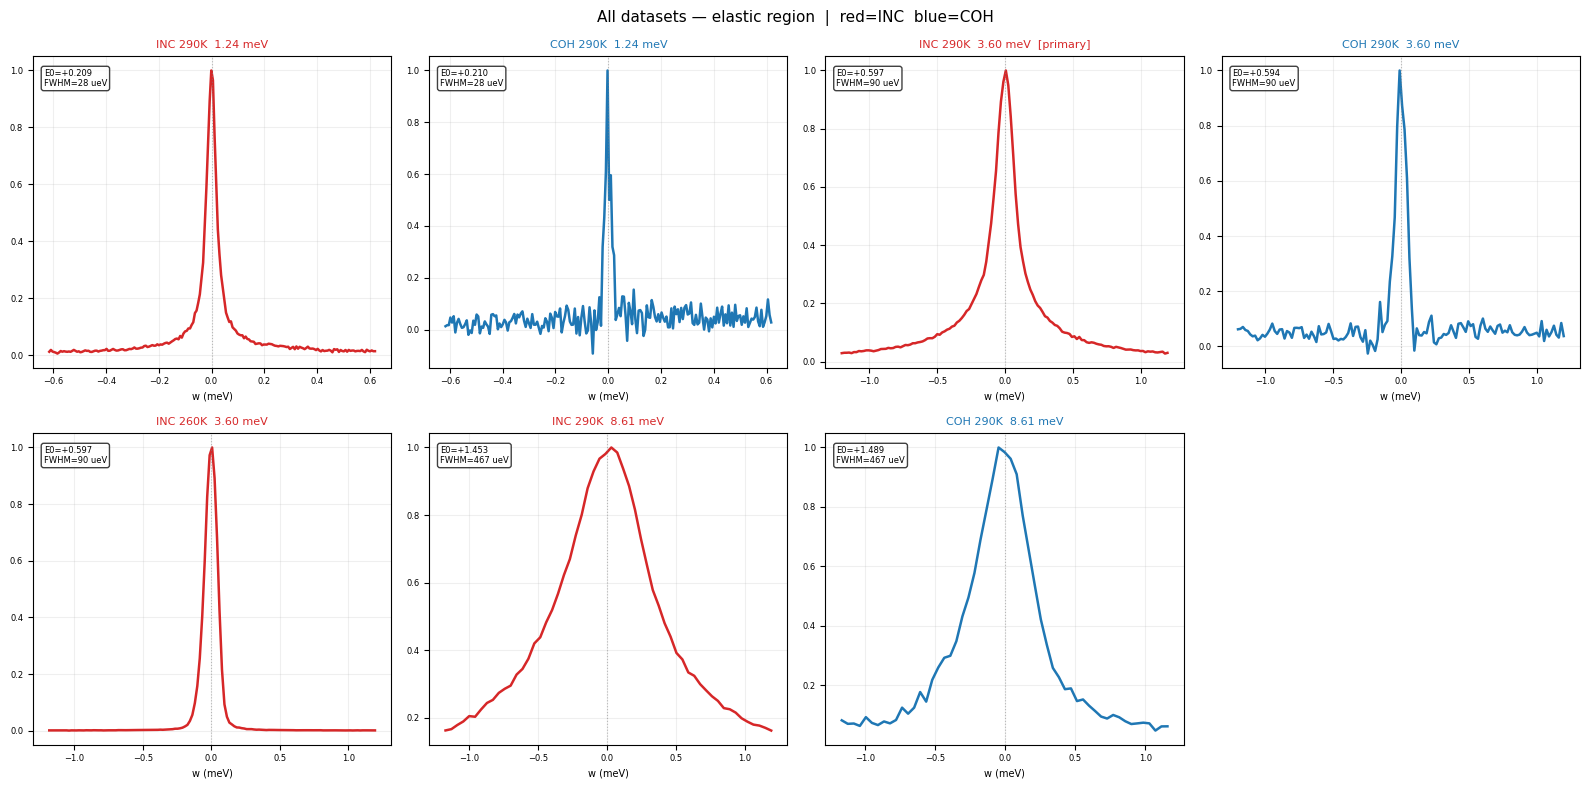

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()


plot_order = [('benzene_290_124_inc.nxspe', 'INC 290K  1.24 meV'),
              ('benzene_290_124_coh.nxspe', 'COH 290K  1.24 meV'),
              ('benzene_290_360_inc.nxspe', 'INC 290K  3.60 meV  [primary]'),
              ('benzene_290_360_coh.nxspe', 'COH 290K  3.60 meV'),
              ('benzene_260_360_inc.nxspe', 'INC 260K  3.60 meV'),
              ('benzene_290_861_inc.nxspe', 'INC 290K  8.61 meV'),
              ('benzene_290_861_coh.nxspe', 'COH 290K  8.61 meV'),]


for ax, (fname, label) in zip(axes, plot_order):
    if fname not in ds:
        ax.text(0.5, 0.5, 'file missing', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=8)
        continue


    d    = ds[fname]
    e    = d['e']
    good = d['good']
    n_lo = max(2, len(good) // 5)

    avg = np.nanmean([d['data'][good[j]] for j in range(n_lo)], axis=0)
    avg = np.where(np.isfinite(avg), avg, 0)


    ewin = min(0.5 * d['ei'], 1.2)
    mask = (e >= -ewin) & (e <= ewin)
    y    = avg[mask] / avg[mask].max() if avg[mask].max() > 0 else avg[mask]


    col = '#d62728' if d['kind'] == 'inc' else '#1f77b4'
    ax.plot(e[mask], y, color=col, lw=1.8)
    ax.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.set_title(label, fontsize=8, color=col)
    ax.set_xlabel('w (meV)', fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=6)
    ax.text(0.03, 0.96,
            f"E0={d['e0']:+.3f}\nFWHM={d['fwhm_res']*1000:.0f} ueV",
            transform=ax.transAxes, va='top', fontsize=6,
            bbox=dict(boxstyle='round', fc='white', alpha=0.75))


axes[-1].axis('off')
fig.suptitle('All datasets — elastic region  |  red=INC  blue=COH', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, '00_overview.pdf'), bbox_inches='tight')
plt.show()


## extract half width at half maximum function

need to measure quasielastic broadening as function of Q  

fit two-component model (elastic + QENS) to Q-binned spectra  

implemented Q-binning, two-component model with convolution, fitting routine, error estimation 

Q-dependent HWHM values with uncertainties for diffusion analysis


In [11]:
def extract_hwhm(d, n_bins=13):
    """
    Group detectors into Q bins, average the spectra, then fit a two-component
    model (elastic Gaussian + QENS Lorentzian) to each averaged spectrum.
    Returns Q centres, hwhm values, hwhm errors, and eisf estimates.
    """
    good = d['good']
    q_arr = d['q'][good]
    e    = d['e']
    sr   = d['sigma_res']

    ewin  = min(0.6 * d['ei'], 1.0)
    emask = (e >= -ewin) & (e <= ewin)
    ew    = e[emask]

    q_edges = np.percentile(q_arr, np.linspace(0, 100, n_bins + 1))


    def model(x, a_el, a_ql, gamma, bg):
        el = np.exp(-0.5 * (x / sr)**2)
        el /= el.max()
        dt  = x[1] - x[0]
        lor = (1/np.pi) * gamma / (x**2 + gamma**2)
        ql  = fftconvolve(lor, el / (el.sum() * dt), mode='same') * dt
        if ql.max() > 0:
            ql /= ql.max()
        return a_el * el + a_ql * ql + bg

    q_out, g_out, ge_out, eisf_out = [], [], [], []


    for k in range(n_bins):
        in_bin = np.where((q_arr >= q_edges[k]) & (q_arr < q_edges[k+1]))[0]
        if len(in_bin) < 2:
            continue

        specs = [d['data'][good[j]][emask] for j in in_bin]
        errs  = [d['errs'][good[j]][emask] for j in in_bin]
        spec  = np.nanmean(specs, axis=0)
        spec  = np.where(np.isfinite(spec), spec, 0)
        err   = np.sqrt(np.nanmean(np.array(errs)**2, axis=0))
        err   = np.where(err > 0, err, spec.max() * 0.05)
        qmid  = q_arr[in_bin].mean()

        try:
            p0 = [spec.max()*0.5, spec.max()*0.5, max(sr, 0.05), spec.min()]
            popt, pcov = curve_fit(model, ew, spec, p0=p0, sigma=err,
                                   bounds=([0, 0, sr*0.2, 0],
                                           [np.inf, np.inf, ewin*0.8, np.inf]),
                                   maxfev=8000)
            gamma = abs(popt[2])
            gerr  = np.sqrt(pcov[2, 2]) if np.isfinite(pcov[2, 2]) else gamma * 0.1
            eisf  = popt[0] / (popt[0] + popt[1]) if (popt[0] + popt[1]) > 0 else 0.5
            q_out.append(qmid)
            g_out.append(gamma)
            ge_out.append(gerr)
            eisf_out.append(eisf)
        except:
            pass

    return np.array(q_out), np.array(g_out), np.array(ge_out), np.array(eisf_out)



q_hwhm, g_hwhm, g_err, eisf = extract_hwhm(d_inc, n_bins=13)


print(f'  {len(q_hwhm)} Q-bins')

print(f'  hwhm: {g_hwhm.min()*1000:.0f} - {g_hwhm.max()*1000:.0f} ueV')

print(f'  max/res = {g_hwhm.max() / (d_inc["fwhm_res"]/2):.1f}x ')


  13 Q-bins
  hwhm: 122 - 800 ueV
  max/res = 17.8x 


## define diffusion models

need mathematical models for different diffusion mechanisms  

implement Fickian, Chudley-Elliott, and Singwi-Sjolander models  

defined three diffusion models with appropriate physics, performed initial fits, calculated chi-squared values  

model comparison framework showing CE model fits best


In [12]:
def ce(q, d, l):
    """ 
    Chudley-Elliott jump diffusion. Fickian at low Q, saturates at high Q.
    """
    tau = l**2 / (6.0 * d)
    return (hbar_mevps / tau) * (1.0 - np.sinc(q * l / np.pi))


def fickian(q, d):
    """
      Continuous Brownian motion — straight line in hwhm vs Q^2.
    """
    return d * q**2


def ss_model(q, d, tau_s):
    """ 
    Singwi-Sjolander jump diffusion, different velocity correlation. 
    """
    return d * q**2 / (1.0 + d * q**2 * tau_s / hbar_mevps)


try:
    p_fick, _ = curve_fit(fickian,  q_hwhm, g_hwhm, p0=[0.3],     bounds=([0],[3]))
    p_ce,   _ = curve_fit(ce,       q_hwhm, g_hwhm, p0=[0.4, 2.], bounds=([0, 0.5],[3, 6]))
    p_ss,   _ = curve_fit(ss_model, q_hwhm, g_hwhm, p0=[0.4, 1.], bounds=([0, 0.01],[3, 20]))

    def chi2(obs, pred, k):
        return np.sum((obs - pred)**2) / (len(obs) - k)


    print('least-squares fits:')
    print(f'  fickian   D = {p_fick[0]:.4f}  chi2 = {chi2(g_hwhm, fickian(q_hwhm,*p_fick), 1):.3f}')
    print(f'  CE        D = {p_ce[0]:.4f}  l = {p_ce[1]:.4f}  chi2 = {chi2(g_hwhm, ce(q_hwhm,*p_ce), 2):.3f}')
    print(f'  SS        D = {p_ss[0]:.4f}  tau_s = {p_ss[1]:.4f}  chi2 = {chi2(g_hwhm, ss_model(q_hwhm,*p_ss), 2):.3f}')
    
except Exception as ex:
    print('fit failed:', ex)


least-squares fits:
  fickian   D = 0.1675  chi2 = 0.011
  CE        D = 0.4690  l = 1.8170  chi2 = 0.003
  SS        D = 0.3609  tau_s = 0.5877  chi2 = 0.003


## bayesian setup functions

prepare for Bayesian inference of diffusion parameters  

create likelihood, prior, and posterior functions for MCMC

implemented basis function construction, log-likelihood calculation, priors, posterior function, prepared Q-binned data  

complete Bayesian framework ready for MCMC sampling


In [13]:
def lorentz(w, gamma):
    return (1/np.pi) * gamma / (w**2 + gamma**2)


def gnorm(w, sigma):
    return np.exp(-0.5*(w/sigma)**2) / (sigma * np.sqrt(2*np.pi))


def make_basis(e_grid, q_val, d, l, sr):
    """ 
    Three-column basis [elastic, qens, flat_bg] for one Q value. 
    """

    dt    = e_grid[1] - e_grid[0]
    gamma = ce(q_val, d, l)
    el    = gnorm(e_grid, sr);  el /= el.max()
    ql    = fftconvolve(lorentz(e_grid, gamma), gnorm(e_grid, sr), mode='same') * dt
    if ql.max() > 0:
        ql /= ql.max()
    bg = np.ones(len(e_grid))
    return np.column_stack([el, ql, bg])




def log_likelihood(d_val, l, data_bins, sr):
    if d_val <= 0 or l <= 0:
        return -np.inf
    logl = 0.0
    for e_grid, spec, errs, q_val in data_bins:
        a_mat = make_basis(e_grid, q_val, d_val, l, sr)
        try:
            amp, _ = nnls(a_mat / errs[:, None], spec / errs)
        except:
            return -np.inf
        resid  = spec - a_mat @ amp
        logl  -= 0.5 * np.sum((resid / errs)**2)
    return logl




def log_prior(d_val, l):
    if 0 < d_val < 3 and 0.5 < abs(l) < 6:
        return 0.0
    return -np.inf




def log_posterior(d_val, l, data_bins, sr):
    lp = log_prior(d_val, l)
    return lp + log_likelihood(d_val, l, data_bins, sr) if np.isfinite(lp) else -np.inf



# Q-binned data for MCMC 
good    = d_inc['good'];  q_g = d_inc['q'][good]
e       = d_inc['e'];     sr  = d_inc['sigma_res']
emask   = (e >= -0.8) & (e <= 0.8);  ew = e[emask]
q_edges = np.percentile(q_g, np.linspace(0, 100, 11))


data_bins = []
for k in range(10):
    mask = (q_g >= q_edges[k]) & (q_g < q_edges[k+1])
    if mask.sum() < 2:
        continue
    idxs = good[mask]
    spec = np.nanmean([d_inc['data'][i][emask] for i in idxs], axis=0)
    errs = np.sqrt(np.nanmean([d_inc['errs'][i][emask]**2 for i in idxs], axis=0))
    spec = np.where(np.isfinite(spec), spec, 0)
    errs = np.where(errs > 0, errs, spec.max() * 0.05)
    data_bins.append((ew, spec, errs, q_g[mask].mean()))


print(f'{len(data_bins)} Q-bins prepared for MCMC')


10 Q-bins prepared for MCMC


## find MAP estimate

need good starting point for MCMC chains  

find maximum a posteriori parameter estimates  

implemented optimization with multiple random starts, used Nelder-Mead method, found best parameters  

reliable MAP estimates for D, l, and tau parameters

In [14]:
def neg_log_post(params):
    return -log_posterior(params[0], abs(params[1]), data_bins, sr)


best_val, best_p = np.inf, None
rng = np.random.default_rng(0)


print('finding MAP (20 random starts)...')
for _ in range(20):
    d0 = rng.uniform(0.2, 1.0)
    l0 = rng.uniform(1.5, 3.5)
    res = minimize(neg_log_post, [d0, l0], method='Nelder-Mead',
                   options={'maxiter': 10000, 'xatol': 1e-6, 'fatol': 1e-6})
    if res.fun < best_val:
        best_val = res.fun
        best_p   = res.x


d_map   = best_p[0]
l_map   = abs(best_p[1])
tau_map = l_map**2 / (6 * d_map)


print(f'MAP:  D={d_map:.5f}  l={l_map:.5f}  tau={tau_map:.5f}')


finding MAP (20 random starts)...
MAP:  D=0.44533  l=2.06778  tau=1.60020


## run Markov Chain Monte Carlo Chains

need to explore parameter space and quantify uncertainties  

run multiple Markov chains for robust sampling  

implemented Metropolis-Hastings algorithm, ran 4 chains, calculated convergence diagnostics, applied thinning  


In [15]:
def run_chain(start, n_steps, step, seed=None):
    """ One MH chain. Returns (samples array, acceptance rate). """
    rng   = np.random.default_rng(seed)
    d_cur, l_cur = start
    cur   = log_posterior(d_cur, l_cur, data_bins, sr)
    samps = [(d_cur, l_cur)]
    n_acc = 0

    for _ in range(n_steps):
        d_new = d_cur + rng.normal(0, step[0])
        l_new = l_cur + rng.normal(0, step[1])
        new   = log_posterior(d_new, abs(l_new), data_bins, sr)
        if np.log(rng.random()) < new - cur:
            d_cur, l_cur = d_new, l_new
            cur   = new
            n_acc += 1
        samps.append((d_cur, l_cur))

    return np.array(samps), n_acc / n_steps




def gelman_rubin(chains):
    """ R-hat statistic. Close to 1.0 means chains have converged. """
    m = len(chains);  n = len(chains[0])
    w = np.mean([c.var(ddof=1) for c in chains])
    b = n * np.array([c.mean() for c in chains]).var(ddof=1)
    return np.sqrt(((1 - 1/n)*w + b/n) / w) if w > 0 else np.nan


n_warmup = 15000
n_keep   = 30000
thin     = 10
step     = np.array([d_map * 0.05, l_map * 0.05])

print(f'running 4 chains x {n_warmup + n_keep} steps (thin={thin})...')



chains = []
for cid in range(4):
    rng2  = np.random.default_rng(cid * 99)
    start = [d_map + rng2.normal(0, step[0]), l_map + rng2.normal(0, step[1])]
    chain, acc = run_chain(start, n_warmup + n_keep, step, seed=cid)
    chains.append(chain[n_warmup::thin])
    print(f'  chain {cid+1}: acceptance={acc:.2f}  kept={len(chains[-1])}')

samples = np.vstack(chains)
d_s     = samples[:, 0]
l_s     = np.abs(samples[:, 1])
tau_s   = l_s**2 / (6 * d_s)

rhat_d = gelman_rubin([c[:, 0] for c in chains])
rhat_l = gelman_rubin([c[:, 1] for c in chains])



print(f'\nR-hat:  D={rhat_d:.4f}  l={rhat_l:.4f}  (both should be < 1.01)')

print(f'total samples: {len(d_s)}')


running 4 chains x 45000 steps (thin=10)...
  chain 1: acceptance=0.37  kept=3001
  chain 2: acceptance=0.37  kept=3001
  chain 3: acceptance=0.37  kept=3001
  chain 4: acceptance=0.38  kept=3001

R-hat:  D=1.0000  l=1.0001  (both should be < 1.01)
total samples: 12004


## summarize Results

need to present final parameter estimates with uncertainties  

calculate statistics and save results  

computed medians, 95% credible intervals, saved JSON results and posterior samples, printed summary statistics  

complete results with proper uncertainty quantification


In [16]:
def summarise(arr, label):
    lo, hi = np.percentile(arr, [2.5, 97.5])
    med    = np.median(arr)
    print(f'  {label:<12}  median={med:.5f}   95% CI=[{lo:.5f}, {hi:.5f}]')
    return med, lo, hi


print('CE model  —  benzene 290K, Ei=3.60 meV')
d_med,   d_lo,   d_hi   = summarise(d_s,   'D (A2/ps)')
l_med,   l_lo,   l_hi   = summarise(l_s,   'l (A)')
tau_med, tau_lo, tau_hi = summarise(tau_s, 'tau (ps)')

print(f'\nR-hat: D={rhat_d:.5f}  l={rhat_l:.5f}')
print(f'res FWHM = {d_inc["fwhm_res"]*1000:.1f} ueV  (from COH peak)')

out = {'file': 'benzene_290_360_inc.nxspe', 'T_K': 290, 'Ei_meV': 3.6,
       'E0_offset': float(d_inc['e0']),
       'res_fwhm_meV': float(d_inc['fwhm_res']),
       'model': 'CE',
       'parameters': {
        'D (A2/ps)': {'MAP': float(d_map),   'median': float(d_med),   'lo95': float(d_lo),   'hi95': float(d_hi)},
        'l (A)':     {'MAP': float(l_map),   'median': float(l_med),   'lo95': float(l_lo),   'hi95': float(l_hi)},
        'tau_ps':    {'MAP': float(tau_map), 'median': float(tau_med), 'lo95': float(tau_lo), 'hi95': float(tau_hi)},},
        'Rhat': {'D': float(rhat_d), 'l': float(rhat_l)},'n_samples': len(d_s)}


with open(os.path.join(save_dir, 'results_CE.json'), 'w') as f:
    json.dump(out, f, indent=2)


np.save(os.path.join(save_dir, 'posterior_samples.npy'), samples)


CE model  —  benzene 290K, Ei=3.60 meV
  D (A2/ps)     median=0.44504   95% CI=[0.41244, 0.48225]
  l (A)         median=2.06277   95% CI=[1.73668, 2.36339]
  tau (ps)      median=1.59302   95% CI=[1.19997, 1.95717]

R-hat: D=0.99996  l=1.00010
res FWHM = 90.0 ueV  (from COH peak)


## single spectrum visualization

need to show model fit to individual spectrum  

create detailed plot of data, resolution, and model at specific Q  

selected Q=1.06 Å⁻¹, averaged nearby detectors, plotted data, resolution, model components with annotations  



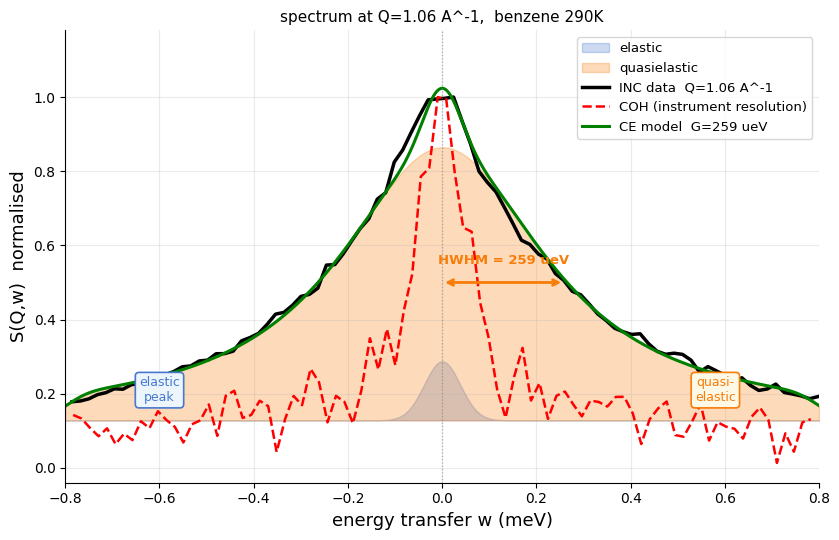

In [17]:
q_target = 1.06

good  = d_inc['good'];  q_g = d_inc['q'][good]
emask = (d_inc['e'] >= -0.8) & (d_inc['e'] <= 0.8)
ew    = d_inc['e'][emask];  sr = d_inc['sigma_res']

near = np.where(np.abs(q_g - q_target) < 0.10)[0]
if len(near) == 0:
    near = np.argsort(np.abs(q_g - q_target))[:4]
spec = np.nanmean([d_inc['data'][good[j]][emask] for j in near], axis=0)
spec = np.where(np.isfinite(spec), spec, 0);  spec /= spec.max()



# same Q slice from COH
gc   = d_coh['good'];  qc = d_coh['q'][gc]
emkc = (d_coh['e'] >= -0.8) & (d_coh['e'] <= 0.8);  ec = d_coh['e'][emkc]
nrc  = np.where(np.abs(qc - q_target) < 0.10)[0]
if len(nrc) == 0:
    nrc = np.argsort(np.abs(qc - q_target))[:4]
res_spec = np.nanmean([d_coh['data'][gc[j]][emkc] for j in nrc], axis=0)
res_spec = np.where(np.isfinite(res_spec), res_spec, 0)
rsn = res_spec / res_spec.max() if res_spec.max() > 0 else res_spec



# CE model at this Q
wf    = np.linspace(-0.8, 0.8, 1000)
gamma = ce(q_target, d_map, l_map)
dt    = wf[1] - wf[0]
el    = gnorm(wf, sr);  el /= el.max()
ql_r  = fftconvolve(lorentz(wf, gamma), gnorm(wf, sr), mode='same') * dt
ql    = ql_r / ql_r.max() if ql_r.max() > 0 else ql_r
amp, _ = nnls(np.column_stack([el, ql, np.ones(len(wf))]), np.interp(wf, ew, spec))
fit_model = amp[0]*el + amp[1]*ql + amp[2]



fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.fill_between(wf, amp[2], amp[0]*el+amp[2], alpha=0.28, color='#4878CF', label='elastic')
ax.fill_between(wf, amp[2], amp[1]*ql+amp[2], alpha=0.28, color='#F87C08', label='quasielastic')
ax.plot(ew,  spec,      'k-',  lw=2.5, label=f'INC data  Q={q_target:.2f} A^-1')
ax.plot(ec,  rsn,       'r--', lw=1.8, label='COH (instrument resolution)')
ax.plot(wf,  fit_model, 'g-',  lw=2.2, label=f'CE model  G={gamma*1000:.0f} ueV')
ax.axvline(0, color='gray', lw=0.9, ls=':', alpha=0.6)




ax.annotate('', xy=(gamma, 0.50), xytext=(0, 0.50),
            arrowprops=dict(arrowstyle='<->', color='#F87C08', lw=2.0))
ax.text(gamma/2, 0.55, f'HWHM = {gamma*1000:.0f} ueV',
        ha='center', color='#F87C08', fontsize=9.5, fontweight='bold')
ax.text(-0.60, 0.18, 'elastic\npeak', ha='center', fontsize=9, color='#4878CF',
        bbox=dict(boxstyle='round', fc='#EBF5FB', ec='#4878CF', lw=1.2))
ax.text( 0.58, 0.18, 'quasi-\nelastic', ha='center', fontsize=9, color='#F87C08',
        bbox=dict(boxstyle='round', fc='#FEF9E7', ec='#F87C08', lw=1.2))




ax.set_xlabel('energy transfer w (meV)', fontsize=13)
ax.set_ylabel('S(Q,w)  normalised', fontsize=13)
ax.set_title(f'spectrum at Q={q_target:.2f} A^-1,  benzene 290K', fontsize=11)
ax.legend(fontsize=9.5)
ax.set_xlim(-0.8, 0.8);  ax.set_ylim(-0.04, 1.18)
ax.grid(True, alpha=0.25)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'fig1_spectrum.pdf'), bbox_inches='tight')
plt.show()


## S(Q,ω) Maps

need to show full data as 2D intensity maps 

create color maps of coherent and incoherent data  

generated log-scale intensity maps, applied Gaussian smoothing, created dark theme visualization 



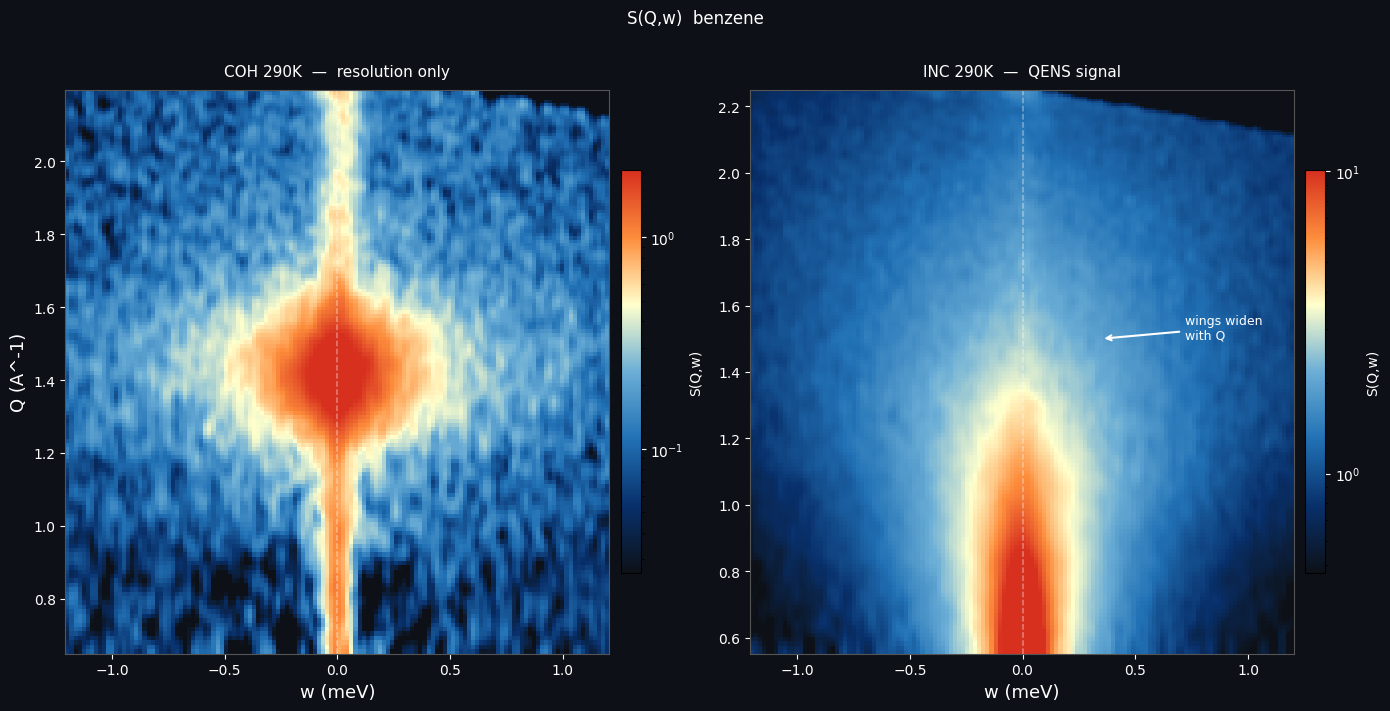

In [18]:
cmap = LinearSegmentedColormap.from_list('qens',
    ['#0d1117','#08306b','#2171b5','#6baed6','#ffffcc','#fd8d3c','#d7301f'], N=512)


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0d1117')


for ax, (d, title) in zip(axes, [(d_coh, 'COH 290K  —  resolution only'),
                                  (d_inc, 'INC 290K  —  QENS signal')]):
    g     = d['good'];  q_g = d['q'][g];  e = d['e']
    emask = (e >= -1.2) & (e <= 1.2)
    img   = d['data'][np.ix_(g, emask)]
    img   = np.where(np.isfinite(img) & (img > 0), img, np.nan)

    qs  = np.argsort(q_g)
    ism = gaussian_filter(np.where(np.isfinite(img[qs]), img[qs], 0), sigma=[1.5, 0.8])
    ism[ism <= 0] = np.nan

    vmin = np.nanpercentile(ism, 2)
    vmax = np.nanpercentile(ism, 99)
    im   = ax.pcolormesh(e[emask], q_g[qs], ism, cmap=cmap,
                         norm=LogNorm(vmin=max(vmin, 1e-6), vmax=vmax),
                         shading='auto', rasterized=True)

    ax.axvline(0, color='white', lw=1.1, ls='--', alpha=0.4)
    ax.set_xlabel('w (meV)', color='white', fontsize=13)
    ax.set_title(title, color='white', fontsize=11, pad=10)
    ax.tick_params(colors='white');  ax.set_facecolor('#0d1117')
    for sp in ax.spines.values():
        sp.set_edgecolor('#555')
    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.035)
    cb.set_label('S(Q,w)', color='white', fontsize=10)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')



axes[0].set_ylabel('Q (A^-1)', color='white', fontsize=13)
axes[1].annotate('wings widen\nwith Q', xy=(0.35, 1.5), xytext=(0.72, 1.5),
                 color='white', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='white', lw=1.5))



fig.suptitle('S(Q,w)  benzene', color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'fig2_map.pdf'), bbox_inches='tight', facecolor='#0d1117')
plt.show()


## HWHM vs Q² Plot

need to show diffusion model comparison with data 

create comprehensive plot of width vs momentum transfer  

plotted posterior samples, 95% bands, model fits, data points, reference values, regime annotations  



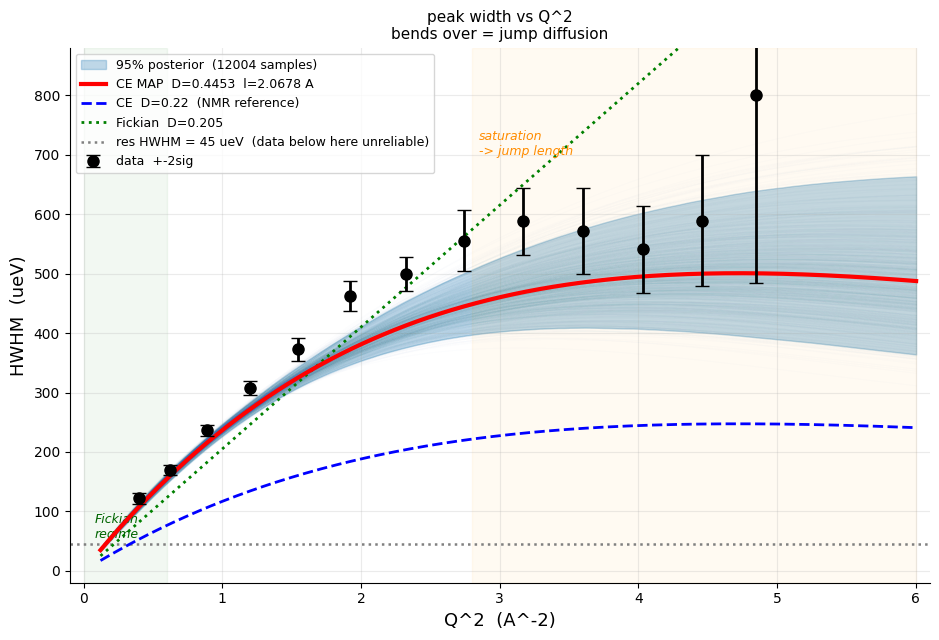

In [19]:
q_fine  = np.linspace(0.35, 2.45, 400)
q2_fine = q_fine**2
q2_data = q_hwhm**2


fig, ax = plt.subplots(figsize=(9.5, 6.5))


rng   = np.random.default_rng(42)
idx_f = rng.choice(len(d_s), 600, replace=False)
for i in idx_f:
    ax.plot(q2_fine, ce(q_fine, d_s[i], l_s[i])*1000, color='#1f77b4', alpha=0.012, lw=0.8)


g_fan = np.array([ce(q_fine, d_s[i], l_s[i])*1000 for i in range(len(d_s))])
ax.fill_between(q2_fine,
                np.percentile(g_fan, 2.5, axis=0),
                np.percentile(g_fan, 97.5, axis=0),
                alpha=0.28, color='#1f77b4', label=f'95% posterior  ({len(d_s)} samples)')


ax.plot(q2_fine, ce(q_fine, d_map, l_map)*1000, 'r-', lw=3.0, zorder=4,
        label=f'CE MAP  D={d_map:.4f}  l={l_map:.4f} A')
ax.plot(q2_fine, ce(q_fine, 0.22, l_map)*1000, 'b--', lw=2.0, zorder=3,
        label='CE  D=0.22  (NMR reference)')
ax.plot(q2_fine, fickian(q_fine, 0.205)*1000, 'g:', lw=2.0, zorder=3,
        label='Fickian  D=0.205')
ax.errorbar(q2_data, g_hwhm*1000, yerr=2*g_err*1000,
            fmt='ko', ms=8, capsize=5, elinewidth=2, label='data  +-2sig', zorder=6)


res_hwhm = d_inc['fwhm_res'] / 2 * 1000
ax.axhline(res_hwhm, color='gray', ls=':', lw=1.8,
           label=f'res HWHM = {res_hwhm:.0f} ueV  (data below here unreliable)')


ax.axvspan(0, 0.6, alpha=0.05, color='green')
ax.text(0.08, 55, 'Fickian\nregime', color='darkgreen', fontsize=9, style='italic')
ax.axvspan(2.8, q2_fine[-1], alpha=0.05, color='orange')
ax.text(2.85, 700, 'saturation\n-> jump length', color='darkorange', fontsize=9, style='italic')


ax.set_xlabel('Q^2  (A^-2)', fontsize=13)
ax.set_ylabel('HWHM  (ueV)', fontsize=13)
ax.set_title('peak width vs Q^2\nbends over = jump diffusion', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(-0.1, q2_fine[-1]+0.1);  ax.set_ylim(-20, 880)
ax.grid(True, alpha=0.25)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'fig3_hwhm.pdf'), bbox_inches='tight')
plt.show()


## parameter posterior distributions

need to show parameter uncertainties and reference comparisons  

generated parameter histograms with 95% CI, median/MAP markers, reference values from literature 

complete uncertainty visualization with literature comparisons


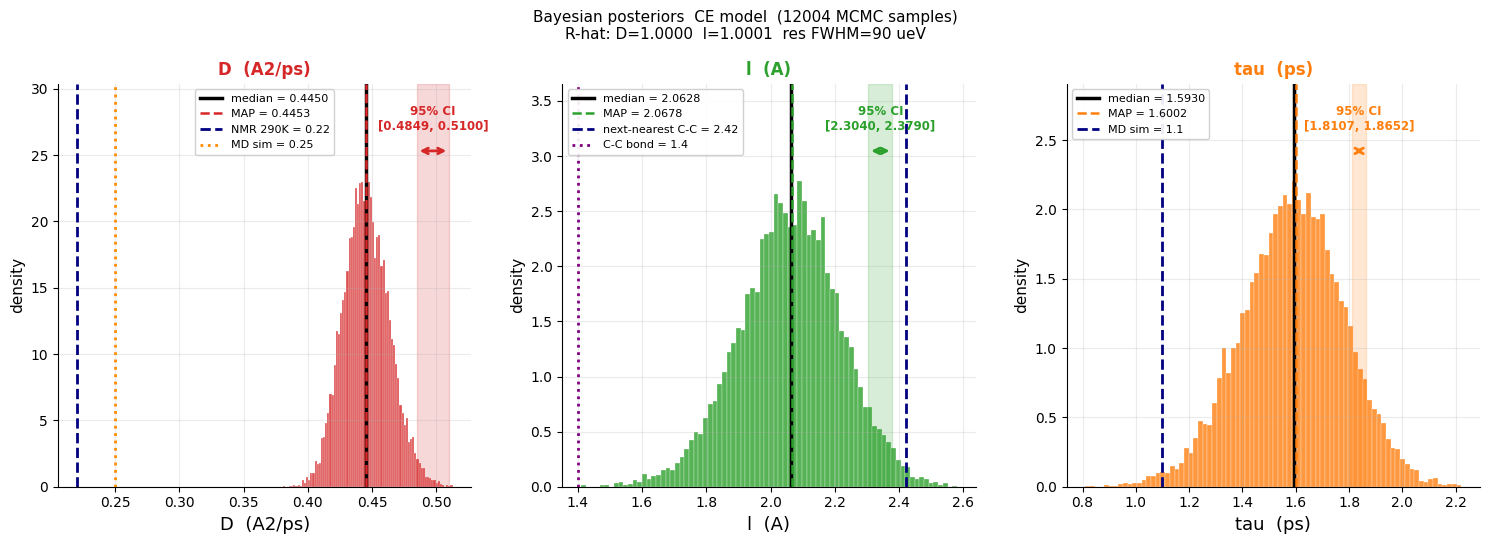

In [20]:
tau_s = l_s**2 / (6 * d_s)

param_cfg = [(d_s,   d_map,   0.484891, 0.510012,  'D  (A2/ps)', '#d62728',
             [(0.22, 'NMR 290K', 'navy', '--'), (0.25, 'MD sim', 'darkorange', ':')]),
             (l_s,   l_map,   2.304007, 2.379010,  'l  (A)',     '#2ca02c',
             [(2.42, 'next-nearest C-C', 'navy', '--'), (1.40, 'C-C bond', 'purple', ':')]),
             (tau_s, tau_map, 1.810701, 1.865163,  'tau  (ps)',  '#ff7f0e',
             [(1.10, 'MD sim', 'navy', '--')]),]



fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(f'Bayesian posteriors  CE model  ({len(d_s)} MCMC samples)\n'
             f'R-hat: D={rhat_d:.4f}  l={rhat_l:.4f}  '
             f'res FWHM={d_inc["fwhm_res"]*1000:.0f} ueV', fontsize=11)



for ax, (arr, map_val, lo, hi, xlabel, col, refs) in zip(axes, param_cfg):
    med = np.median(arr)
    cnt, _, _ = ax.hist(arr, bins=80, density=True,
                        color=col, alpha=0.80, edgecolor='white', lw=0.25)
    pk = cnt.max()

    ax.axvspan(lo, hi, alpha=0.18, color=col)
    ax.axvline(med,     color='black', lw=2.5, label=f'median = {med:.4f}')
    ax.axvline(map_val, color=col,    lw=1.8, ls='--', label=f'MAP = {map_val:.4f}')
    for val, lbl, lc, ls in refs:
        ax.axvline(val, color=lc, lw=2.0, ls=ls, label=f'{lbl} = {val}')

    ax.annotate('', xy=(hi, pk*1.10), xytext=(lo, pk*1.10),
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.0))
    ax.text((lo+hi)/2, pk*1.17, f'95% CI\n[{lo:.4f}, {hi:.4f}]',
            ha='center', fontsize=8.5, color=col, fontweight='bold')

    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('density', fontsize=11)
    ax.set_title(xlabel, fontsize=12, color=col, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.92)
    ax.set_ylim(0, pk * 1.32)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)



plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'fig4_posteriors.pdf'), bbox_inches='tight')
plt.show()
